# Exercise: The Higgs Boson Discovery

**The Scenario:**
It is 2012. You are a particle physicist at CERN analyzing data from the Large Hadron Collider. You are searching for the elusive Higgs boson, which theory predicts should decay into pairs of photons. You have just collected your first dataset.

**The Data:**
You are given a dataset containing the invariant mass of photon pairs measured by your detector, ranging from 100 GeV to 150 GeV. The histogram below shows the real data you collected! Your task is to use this spectrum to claim a discovery and measure the mass of the new particle.

**Part 1: Hypothesis Testing via Sideband Fit**
To claim a discovery, you must first estimate the expected number of background events that fall inside the expected signal region, in order to show that the observed data is inconsistent with background-only fluctuations.

Standard Model background processes are known to produce a smoothly falling exponential distribution: $f(m) \propto e^{-\lambda m}$. You decide to look for the Higgs in the **Signal Region: [120, 130] GeV**.

1.  **Create the Sideband Dataset:** Create a "sideband" dataset by masking out all events that fall inside the [120, 130] GeV signal window.
2.  **Fit the Background Shape:** Use `iminuit` and `UnbinnedNLL` to fit the decay parameter $\lambda$ using *only* your sideband data.
    * *N.B.: You must take care to normalise the background PDF in the sideband region: the PDF integral over the two sidebands should be normalised to 1.*
3.  **The Hypothesis Test:**
    * Using your fitted value $\hat{\lambda}$, calculate the expected number of background events ($b$) that should have landed *inside* the [120, 130] GeV signal window. (Hint: This is the total number of events in the sideband multiplied by the ratio of the integrals of the PDF over the signal and sideband regions.)
    * Count the actual number of observed events ($N_{obs}$) that fall inside the signal window.
    * Calculate the Poisson p-value of observing $N_{obs}$ or more events given the expected background $b$. Do you claim a discovery of the Higgs boson with a significance of at least $5\sigma$?



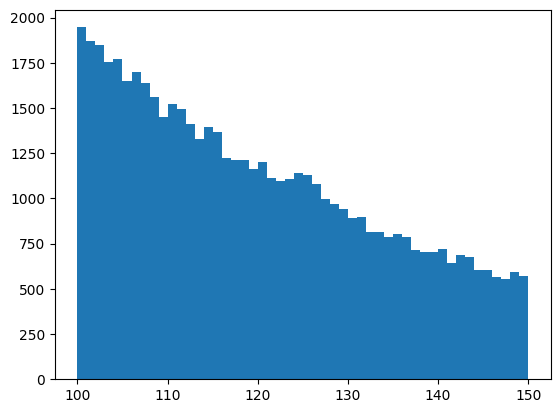

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# The modified Google Drive direct-download link
url = 'https://drive.google.com/uc?export=download&id=1AauqtqMTm5MT4b57NHOnxytsJgBSvhGX'
df = pd.read_csv(url)

plt.hist(df['mass_gev'], bins=50, range=(100, 150));
masses = df['mass_gev']
plt.show()
#@title { vertical-output: true}



In [ ]:
!pip install iminuit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 7.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import urllib.request
from scipy.stats import poisson


Events in sideband: 44640


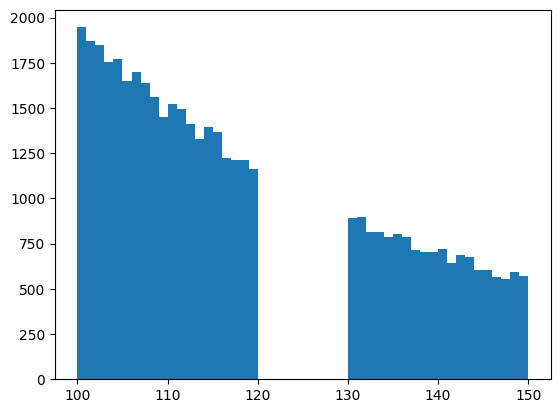

In [ ]:
# Create Sideband Dataset
m_min, m_max = 100.0, 150.0
sig_min, sig_max = 120.0, 130.0

# Boolean mask: True if an event is in the signal region
in_signal = (masses >= sig_min) & (masses <= sig_max)

# Sideband data is everything NOT in the signal region
data_sb = masses[~in_signal]
N_sb = len(data_sb)
print(f"Events in sideband: {N_sb}")

plt.hist(data_sb, bins=50, range=(100, 150))
plt.show()
#@title { vertical-output: true}


In [ ]:
import numpy as np

def pdf_sideband(m, lam):
    """
    Custom exponential PDF, manually normalized over the two disjoint
    sideband regions: [100, 120] and [130, 150].
    """
    # Integral of unnormalized e^(-lam * m) over the left sideband
    int_left = (np.exp(-lam * m_min) - np.exp(-lam * sig_min)) / lam

    # Integral over the right sideband
    int_right = (np.exp(-lam * sig_max) - np.exp(-lam * m_max)) / lam

    # Total normalization constant
    norm_factor = int_left + int_right

    return np.exp(-lam * m) / norm_factor




Fitted background decay parameter: lambda = 0.02571


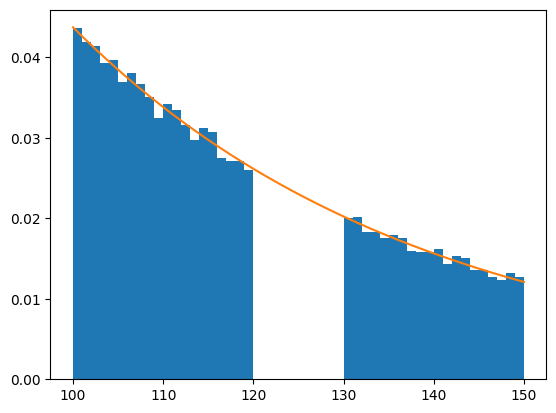

In [ ]:
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL

# Set up UnbinnedNLL and Minuit
nll_sb = UnbinnedNLL(data_sb, pdf_sideband)
m_fit = Minuit(nll_sb, lam=0.01) # Initial guess for lambda
m_fit.limits['lam'] = (0.0001, 1.0) # Decay constant must be positive

# Run the minimization
m_fit.migrad()
lam_hat = m_fit.values['lam']

print(f"\nFitted background decay parameter: lambda = {lam_hat:.5f}")

# plot the histogram and the pdf on top
plt.hist(data_sb, bins=50, range=(100, 150), density=True)
x = np.linspace(100, 150, 1000)
plt.plot(x, pdf_sideband(x, lam_hat), label='Fitted PDF')
plt.show()
#@title { vertical-output: true}


In [ ]:
# Calculate expected background (b) in the signal region
# We need the integral of the unnormalized exponential over the signal region
int_signal = (np.exp(-lam_hat * sig_min) - np.exp(-lam_hat * sig_max)) / lam_hat
int_left = (np.exp(-lam_hat * m_min) - np.exp(-lam_hat * sig_min)) / lam_hat
int_right = (np.exp(-lam_hat * sig_max) - np.exp(-lam_hat * m_max)) / lam_hat

# b = (Total sideband events) * (Ratio of probability areas)
expected_b = N_sb * (int_signal / (int_left + int_right))
print(f"Expected background in signal region (b): {expected_b:.1f}")

Expected background in signal region (b): 10293.5


In [ ]:
# Count actual observed events in the signal window
N_obs = np.sum(in_signal)
print(f"Observed events in signal region (N_obs): {N_obs}")


Observed events in signal region (N_obs): 10760


In [ ]:
from scipy.stats import poisson
# Calculate Poisson p-value: P(N >= N_obs | expected_b)
# sf(k) calculates P(N > k), so we use N_obs - 1
p_val = poisson.sf(N_obs - 1, mu=expected_b)

print(f"\n--- Hypothesis Test Results ---")
print(f"Expected background in signal region (b): {expected_b:.1f}")
print(f"Observed events in signal region (N_obs): {N_obs}")
print(f"p-value: {p_val:.3e}")


--- Hypothesis Test Results ---
Expected background in signal region (b): 10293.5
Observed events in signal region (N_obs): 10760
p-value: 2.552e-06


In [ ]:
# Transform the p-value into a one-sided Z-score
import scipy.stats as stats
z_score = stats.norm.ppf(1 - p_val)
print(f"Z-score: {z_score:.2f} sigmas")

Z-score: 4.56 sigmas


**Part 2: Measuring the Higgs Mass**
Now that you have discovered the particle, you need to measure its properties! Instead of cutting out the signal region, you will now fit the **entire dataset** from 100 GeV to 150 GeV.

Your detector's energy resolution for photon pairs is known to be exactly 1.5 GeV. Fix your Gaussian signal width ($\sigma$) to 1.5 GeV and assume it is a simple Gaussian. Construct a composite probability density function that is a mixture of an exponential background and a Gaussian signal.

Use `iminuit` and `UnbinnedNLL` to perform a 3-parameter fit on the full dataset to find:
1.  The signal fraction ($f_{sig}$)
2.  The Higgs boson mass ($\mu$) (the center of the Gaussian)
3.  The background decay rate parameter ($\lambda$)
    *(Remember to properly normalize both the exponential and Gaussian components over the full [100, 150] GeV range!)*

**Results:** What is the measured mass of your newly discovered Higgs boson, including its uncertainty?

In [ ]:
from scipy.stats import norm
# --- Define the Composite PDF ---
m_min, m_max = 100.0, 150.0
fixed_sigma = 1.5 # The known detector resolution

def pdf_composite(m, f_sig, mu, lam):
    """
    Composite PDF: (1 - f_sig) * Background + f_sig * Signal
    Both components must be individually normalized over the [100, 150] range!
    """
    # 1. Background Component (Exponential)
    # Integral of e^(-lam * m) from 100 to 150
    bkg_norm = (np.exp(-lam * m_min) - np.exp(-lam * m_max)) / lam
    pdf_bkg = np.exp(-lam * m) / bkg_norm

    # 2. Signal Component (Gaussian)
    # To normalize a truncated Gaussian, we use the Cumulative Distribution Function (CDF)
    # The integral of the Gaussian between m_min and m_max is CDF(m_max) - CDF(m_min)
    sig_norm = norm.cdf(m_max, loc=mu, scale=fixed_sigma) - norm.cdf(m_min, loc=mu, scale=fixed_sigma)
    pdf_sig = norm.pdf(m, loc=mu, scale=fixed_sigma) / sig_norm

    # 3. Combine them
    return (1.0 - f_sig) * pdf_bkg + f_sig * pdf_sig


In [ ]:
# --- Set up the Fit ---
nll_comp = UnbinnedNLL(masses, pdf_composite)

# Initialize Minuit with starting guesses
# We guess a 1% signal fraction, a mass near 125, and a lambda near 0.02
m_comp = Minuit(nll_comp, f_sig=0.01, mu=125.0, lam=0.02)

# Set physical limits on the parameters
m_comp.limits['f_sig'] = (0.0, 1.0)        # Fraction must be between 0 and 100%
m_comp.limits['mu'] = (120.0, 130.0)       # We expect the mass to be in this window
m_comp.limits['lam'] = (0.0001, 1.0)       # Decay constant must be positive

# --- Run the Minimization ---
m_comp.migrad()  # Find the minimum
#@title { vertical-output: true}

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.262e+05                  │              Nfcn = 77               │
│ EDM = 2.11e-05 (Goal: 0.0002)    │            time = 1.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_sig │  0.0075   │  0.0015   │            │            │    0    │    1    │       │
│ 1 │ mu    │   125.4   │    0.4    │            │            │   120   │   130   │       │
│ 2 │ lam   │ 25.68e-3  │  0.31e-3  │            │            │ 0.0001  │    1    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │    f_sig       mu      lam │
├───────┼────────────────────────────┤
│ f_sig │ 2.15e-06 -26.5e-6  0.06e-6 │
│    mu │ -26.5e-6    0.142  4.56e-6 │
│   lam │  0.06e-6  4.56e-6 9.66e-08 │
└───────┴────────────────────────────┘

## Bonus: fit with `zfit`

In [ ]:
!pip install zfit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.2/473.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.4/395.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 41.1 MB/s eta 0:00:00


In [ ]:
import zfit

# --- Define the Physics Space & Data ---
# This is the magic of zfit: defining this Space means all PDFs
# will be automatically normalized strictly between 100 and 150!
obs = zfit.Space('mass_gev', limits=(100.0, 150.0))

# Convert the raw NumPy array into a zfit Data object
data = zfit.Data.from_numpy(obs=obs, array=np.array(masses))

# --- Define the Parameters ---
# zfit.Parameter(name, initial_value, lower_limit, upper_limit)
mu = zfit.Parameter("mu", 125.0, 120.0, 130.0)
sigma = zfit.Parameter("sigma", 1.5, floating=False) # Fix the width to 1.5
f_sig = zfit.Parameter("f_sig", 0.01, 0.0, 1.0)      # Signal fraction

# Note: zfit's built-in Exponential is e^(lambda * x).
# Since our background is decaying, we must use a negative lambda
lam = zfit.Parameter("lambda", -0.02, -1.0, -0.0001)

# --- Build the Composite Model ---
# Create the individual shapes
sig_pdf = zfit.pdf.Gauss(obs=obs, mu=mu, sigma=sigma)
bkg_pdf = zfit.pdf.Exponential(obs=obs, lam=lam)

# Add them together! SumPDF handles the (1 - f_sig) math automatically.
model = zfit.pdf.SumPDF(pdfs=[sig_pdf, bkg_pdf], fracs=[f_sig])

# --- Fit the Model to the Data ---
# Create the Negative Log-Likelihood cost function
nll = zfit.loss.UnbinnedNLL(model=model, data=data)

# We still use Minuit under the hood as the minimizer engine
minimizer = zfit.minimize.Minuit()

# Run the fit and calculate errors (Hessian)
result = minimizer.minimize(nll)
result.hesse()

# --- Print the Results ---
print(result)

/usr/local/lib/python3.12/dist-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_0, f_sig]] data=[<zfit.Data: Data obs=('mass_gev',) shape=(55400, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 5.7e-05 │        213116.01 |  9822.908 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)        hesse    at limit
------  ------------------  -----------  ----------
f_sig           0.00746654  +/-  0.0015       False
mu                 125.427  +/-    0.38       False
lambda          -0.0256845  +/- 0.00031       False


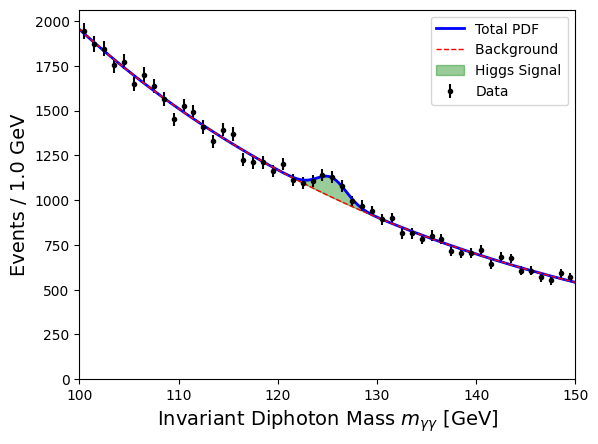

In [ ]:
# Define the bins (e.g., 25 bins from 100 to 150 GeV gives 2 GeV per bin)
n_bins = 50
bin_edges = np.linspace(100, 150, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]

# Calculate histogram counts and Poisson error bars (sqrt(N))
counts, _ = np.histogram(masses, bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
err_counts = np.sqrt(counts)

# Plot the data as black dots with error bars (standard in particle physics)
plt.errorbar(bin_centers, counts, yerr=err_counts, fmt='ko', markersize=3, label='Data')

# --- Evaluate the zfit Models ---
# Create a dense array of x-values to draw smooth curves
x_plot = np.linspace(100, 150, 1000)

# The scaling factor to convert a normalized PDF into Expected Events per Bin
scaling_factor = len(masses) * bin_width

# Extract the fitted signal fraction
f_sig_val = f_sig.value().numpy()

# Get the probability density values (numpy arrays) from the zfit models
# Note: model.pdf(x) requires the x-values to be passed as a 1D numpy array
pdf_tot_y = model.pdf(x_plot).numpy()
pdf_bkg_y = bkg_pdf.pdf(x_plot).numpy()
pdf_sig_y = sig_pdf.pdf(x_plot).numpy()

# Scale them appropriately
y_tot = pdf_tot_y * scaling_factor
y_bkg = pdf_bkg_y * scaling_factor * (1.0 - f_sig_val)
y_sig = pdf_sig_y * scaling_factor * f_sig_val

# --- Draw the Fit Curves ---
# Total Fit
plt.plot(x_plot, y_tot, color='blue', linewidth=2, label='Total PDF')

# Background Component
plt.plot(x_plot, y_bkg, color='red', linestyle='--', linewidth=1, label='Background ')

# Signal Component (Shaded area sitting on top of the background)
plt.fill_between(x_plot, y_bkg, y_bkg + y_sig, color='green', alpha=0.4,
                 label=f'Higgs Signal')

# --- Final Formatting ---
plt.xlabel(r'Invariant Diphoton Mass $m_{\gamma\gamma}$ [GeV]', fontsize=14)
plt.ylabel(f'Events / {bin_width:.1f} GeV', fontsize=14)
plt.xlim(100, 150)
plt.ylim(0, None)
plt.legend()
plt.show()
#@title { vertical-output: true}